In [11]:
# Step 1: Imports 
import numpy as np
import pandas as pd
import json
import os
import re
import string
import pickle
import matplotlib.pyplot as plt
from collections import Counter

# Importing all the tensorflow libraries
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import seaborn as sns

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [12]:
# Step 2: Load dataset 
train_df = pd.read_csv("data/train.csv")
test_df  = pd.read_csv("data/test.csv")

with open("data/label_map.json") as f:
    label_map = json.load(f)

print(f"Train: {len(train_df):,} rows")
print(f"Test : {len(test_df):,} rows")
print(f"Classes: {len(label_map)}")
print("\nSample:")
train_df.head()

Train: 4,695 rows
Test : 1,174 rows
Classes: 56

Sample:


,text,label
0,chest tightness dry cough fever cannot smell o...,COVID-19
1,ive had sleep apnea loud snoring breathing sto...,Sleep Apnea
2,diarrhea frequent watery stools cramps urgency...,Diarrhea
3,high fever body aches chills,Influenza
4,severe headache dizziness nosebleed blood pres...,High Blood Pressure Symptoms


In [13]:
#  Step 4: Text cleaning - NLP 
def clean_text(text):
    # Convert to lower case 
    text = str(text).lower()
    # remove all punctuations
    text = text.translate(str.maketrans('', '', string.punctuation))
    # remove all the extra spaces 
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Applying this clean text function to both train and test data 
train_df["text"] = train_df["text"].apply(clean_text)
test_df["text"]  = test_df["text"].apply(clean_text)


In [14]:
# Step 5: Label encoding  
le = LabelEncoder()
le.fit(sorted(train_df["label"].unique()))

y_train = le.transform(train_df["label"])
y_test  = le.transform(test_df["label"])

num_classes = len(le.classes_)
print(f"Number of classes: {num_classes}")
print("Classes:", list(le.classes_))

Number of classes: 56
Classes: [np.str_('Acidity / GERD'), np.str_('Allergy'), np.str_('Anemia'), np.str_('Angina Awareness'), np.str_('Anxiety'), np.str_('Appendicitis'), np.str_('Arthritis'), np.str_('Asthma'), np.str_('Back Pain'), np.str_('Bronchitis'), np.str_('COVID-19'), np.str_('Chickenpox'), np.str_('Common Cold'), np.str_('Conjunctivitis'), np.str_('Constipation'), np.str_('Dehydration'), np.str_('Dengue Fever'), np.str_('Depression'), np.str_('Diabetes'), np.str_('Diarrhea'), np.str_('Ear Infection'), np.str_('Eczema'), np.str_('Edema'), np.str_('Fatigue'), np.str_('Food Poisoning'), np.str_('Fungal Infection'), np.str_('Gastroenteritis'), np.str_('General Weakness'), np.str_('Gout'), np.str_('Hepatitis A'), np.str_('High Blood Pressure Symptoms'), np.str_('Hives'), np.str_('Hypothyroidism'), np.str_('IBS'), np.str_('Influenza'), np.str_('Joint Inflammation'), np.str_('Kidney Stones'), np.str_('Low Risk / General Condition'), np.str_('Malaria'), np.str_('Migraine'), np.str_(

In [15]:
# Step 6: Tokenisation & padding 

MAX_WORDS = 15000   # vocabulary size
MAX_LEN   = 120     # max tokens per sample

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["text"])

X_train = pad_sequences(
    tokenizer.texts_to_sequences(train_df["text"]),
    maxlen=MAX_LEN, padding="post", truncating="post"
)
X_test = pad_sequences(
    tokenizer.texts_to_sequences(test_df["text"]),
    maxlen=MAX_LEN, padding="post", truncating="post"
)

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)

In [16]:
# Step 7: Class weights (handles imbalance)

# making all the classes having balanced weights 
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights_array))

In [17]:
MAX_LEN

120

In [18]:
# Step 8: Bidirectional LSTM model 
EMBEDDING_DIM = 128

model = Sequential([
    Embedding(vocab_size, EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.4),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Step 9: Train the model 
os.makedirs("model", exist_ok=True)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor="val_accuracy"),
    ModelCheckpoint("model/symptom_model1.h5", save_best_only=True, monitor="val_accuracy"),
    ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, min_lr=1e-6),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.0392 - loss: 3.9268

147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - accuracy: 0.0935 - loss: 3.5709 - val_accuracy: 0.5153 - val_loss: 1.9688 - learning_rate: 0.0010
Epoch 2/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.4707 - loss: 1.7323

147/147 ━━━━━━━━━━━━━━━━━━━━ 27s 181ms/step - accuracy: 0.5896 - loss: 1.3388 - val_accuracy: 0.9216 - val_loss: 0.3976 - learning_rate: 0.0010
Epoch 3/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.8500 - loss: 0.5357

147/147 ━━━━━━━━━━━━━━━━━━━━ 36s 242ms/step - accuracy: 0.8707 - loss: 0.4617 - val_accuracy: 0.9514 - val_loss: 0.1715 - learning_rate: 0.0010
Epoch 4/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.9239 - loss: 0.2811

147/147 ━━━━━━━━━━━━━━━━━━━━ 43s 293ms/step - accuracy: 0.9282 - loss: 0.2626 - val_accuracy: 0.9796 - val_loss: 0.0820 - learning_rate: 0.0010
Epoch 5/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9616 - loss: 0.1637

...

147/147 ━━━━━━━━━━━━━━━━━━━━ 68s 465ms/step - accuracy: 0.9768 - loss: 0.0885 - val_accuracy: 0.9923 - val_loss: 0.0306 - learning_rate: 0.0010
Epoch 8/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 57s 290ms/step - accuracy: 0.9870 - loss: 0.0609 - val_accuracy: 0.9855 - val_loss: 0.0562 - learning_rate: 0.0010
Epoch 9/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 25s 172ms/step - accuracy: 0.9851 - loss: 0.0606 - val_accuracy: 0.9855 - val_loss: 0.0327 - learning_rate: 0.0010
Epoch 10/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 33s 221ms/step - accuracy: 0.9821 - loss: 0.0684 - val_accuracy: 0.9889 - val_loss: 0.0383 - learning_rate: 0.0010
Epoch 11/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.9895 - loss: 0.0427

147/147 ━━━━━━━━━━━━━━━━━━━━ 35s 241ms/step - accuracy: 0.9934 - loss: 0.0323 - val_accuracy: 0.9940 - val_loss: 0.0167 - learning_rate: 5.0000e-04
Epoch 12/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9951 - loss: 0.0273

147/147 ━━━━━━━━━━━━━━━━━━━━ 32s 215ms/step - accuracy: 0.9947 - loss: 0.0265 - val_accuracy: 0.9949 - val_loss: 0.0157 - learning_rate: 5.0000e-04
Epoch 13/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 31s 212ms/step - accuracy: 0.9962 - loss: 0.0207 - val_accuracy: 0.9949 - val_loss: 0.0177 - learning_rate: 5.0000e-04
Epoch 14/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9976 - loss: 0.0152

147/147 ━━━━━━━━━━━━━━━━━━━━ 32s 220ms/step - accuracy: 0.9962 - loss: 0.0181 - val_accuracy: 0.9957 - val_loss: 0.0157 - learning_rate: 5.0000e-04
Epoch 15/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.9984 - loss: 0.0147

147/147 ━━━━━━━━━━━━━━━━━━━━ 32s 218ms/step - accuracy: 0.9968 - loss: 0.0173 - val_accuracy: 0.9983 - val_loss: 0.0088 - learning_rate: 5.0000e-04
Epoch 16/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 33s 225ms/step - accuracy: 0.9949 - loss: 0.0241 - val_accuracy: 0.9957 - val_loss: 0.0118 - learning_rate: 5.0000e-04
Epoch 17/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 45s 307ms/step - accuracy: 0.9962 - loss: 0.0167 - val_accuracy: 0.9949 - val_loss: 0.0144 - learning_rate: 5.0000e-04
Epoch 18/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 32s 219ms/step - accuracy: 0.9936 - loss: 0.0250 - val_accuracy: 0.9923 - val_loss: 0.0270 - learning_rate: 5.0000e-04
Epoch 19/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 32s 219ms/step - accuracy: 0.9951 - loss: 0.0190 - val_accuracy: 0.9983 - val_loss: 0.0090 - learning_rate: 2.5000e-04
Epoch 20/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 32s 215ms/step - accuracy: 0.9964 - loss: 0.0164 - val_accuracy: 0.9966 - val_loss: 0.0104 - learning_rate: 2.5000e-04


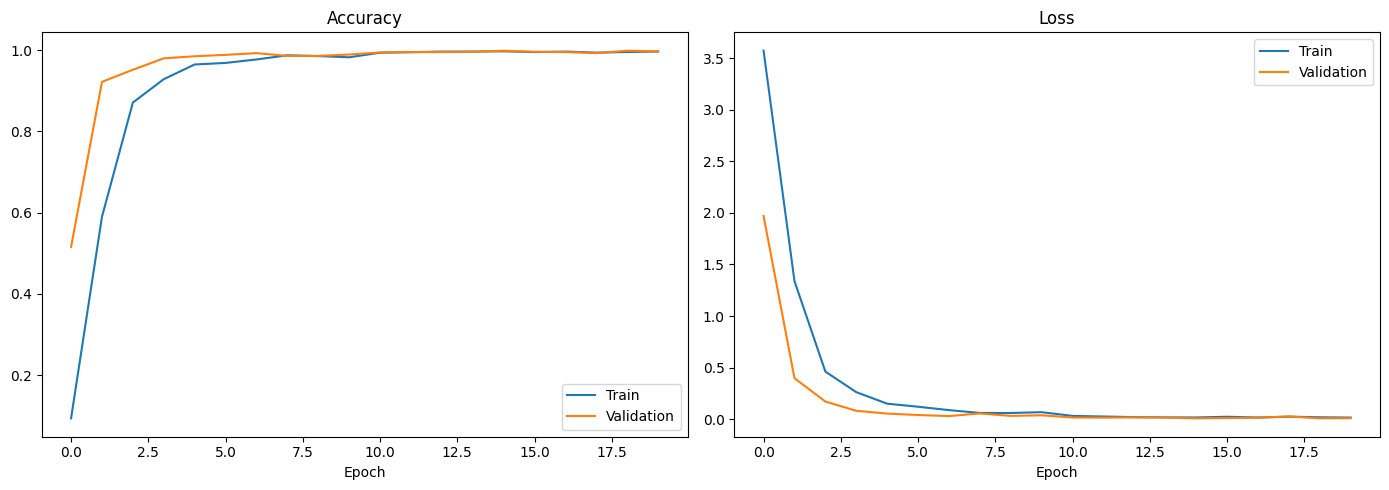

In [20]:
# Step 10: Training curves - displaying the graphs 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history["accuracy"], label="Train")
ax1.plot(history.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy")
ax1.legend()
ax1.set_xlabel("Epoch")

ax2.plot(history.history["loss"], label="Train")
ax2.plot(history.history["val_loss"], label="Validation")
ax2.set_title("Loss")
ax2.legend()
ax2.set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("model/training_curves.png", dpi=150)
plt.show()

In [21]:
# Step 11: Save all files 
model.save("model/symptom_model1.h5")

with open("model/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("model/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

with open("model/label_map.json", "w") as f:
    json.dump({cls: int(idx) for idx, cls in enumerate(le.classes_)}, f, indent=2)

print("✅ Saved:")
print("   model/symptom_model1.h5")
print("   model/tokenizer.pkl")
print("   model/label_encoder.pkl")
print("   model/label_map.json")


✅ Saved:
   model/symptom_model1.h5
   model/tokenizer.pkl
   model/label_encoder.pkl
   model/label_map.json


In [22]:
import sys
print(sys.executable)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\python.exe


In [1]:
y_pred_probs = model.predict(X_test_pad)

# Convert probabilities → class labels
y_pred = np.argmax(y_pred_probs, axis=1)

NameError: name 'model' is not defined